# JUMP → AnnData

Builds an AnnData object from the assembled well-level CellProfiler profiles of the
[JUMP Cell Painting Consortium](https://github.com/jump-cellpainting/datasets)
([Chandrasekaran et al. 2023](https://doi.org/10.1101/2023.03.23.534023)).
One observation is a well, one variable is a CellProfiler feature.

Everything is driven by a checkout of the metadata repository, which carries the
profile manifest and the experimental metadata tables but not the profiles themselves:

```bash
git clone https://github.com/jump-cellpainting/datasets ~/data/jump-cellpainting-datasets
```

The profiles listed in `manifests/profile_index.json` live in the public
[Cell Painting Gallery](https://registry.opendata.aws/cellpainting-gallery/) S3 bucket
and are fetched on first use.

In [1]:
from __future__ import annotations

import json
from collections.abc import Iterable, Sequence
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

DATA_ROOT = Path("~/data/jump-cellpainting-datasets").expanduser()
SUBSET = "crispr"  # compound, orf, or crispr; the per-modality annotation below is keyed to it

## Loading a subset

Each modality ships two assembled profile sets built by the
[jump-profiling-recipe](https://github.com/broadinstitute/jump-profiling-recipe).
The `*_interpretable` set stops after well-position and cell-count correction,
per-plate MAD robustization, outlier removal, and feature selection, so its
columns are still named CellProfiler measurements.
The default set continues into sphering and Harmony batch correction, which
rotate the features into anonymous components; those are the right input for
retrieval benchmarks but carry no per-feature meaning, so this notebook takes
the interpretable set.

Feature selection ran once over the assembled subset, so every plate shares the
same variables. Combining subsets still requires intersecting variables first.

In [2]:
def profile_url(root: Path, subset: str) -> str:
    index = json.loads((root / "manifests" / "profile_index.json").read_text())
    key = f"{subset}_interpretable"
    try:
        return next(entry["url"] for entry in index if entry["subset"] == key)
    except StopIteration:
        raise KeyError(f"{key!r} not in profile_index.json") from None


def fetch_profiles(root: Path, subset: str) -> Path:
    dest = root / "profiles" / f"{subset}_interpretable.parquet"
    if not dest.exists():
        import fsspec

        url = profile_url(root, subset)
        dest.parent.mkdir(parents=True, exist_ok=True)
        print(f"fetching {url}")
        with fsspec.open(url) as src, dest.open("wb") as out:
            while chunk := src.read(1 << 24):
                out.write(chunk)
    return dest


def load_profiles(root: Path, subset: str) -> ad.AnnData:
    df = pd.read_parquet(fetch_profiles(root, subset))
    meta_cols = [c for c in df.columns if c.startswith("Metadata_")]
    feature_cols = [c for c in df.columns if c not in meta_cols]

    obs = df[meta_cols].rename(columns=lambda c: c.removeprefix("Metadata_"))
    obs.index = pd.Index(obs["Source"] + ":" + obs["Plate"] + ":" + obs["Well"], name="well")
    var = pd.DataFrame(index=pd.Index(feature_cols, name="feature"))

    adata = ad.AnnData(X=df[feature_cols].to_numpy(np.float32), obs=obs, var=var)
    adata.uns["subset"] = subset
    adata.uns["profile_url"] = profile_url(root, subset)
    return adata


adata = load_profiles(DATA_ROOT, SUBSET)
adata

AnnData object with n_obs × n_vars = 51185 × 3651
    obs: 'Source', 'Plate', 'Well', 'JCP2022'
    uns: 'subset', 'profile_url'
    layers: None (.X)

## Well and plate annotation

The profiles carry the plate barcode, well position, and a `JCP2022` perturbation
id per well. The metadata tables resolve the rest: `plate` adds the batch and
plate type, `perturbation_control` flags the negative and positive controls, and
the per-modality table names what each well was treated with — gene symbol and
NCBI id for `crispr` / `orf`, `InChIKey` / `SMILES` for `compound`.

In [3]:
PERTURBATION_COLUMNS = {
    "compound": ["InChIKey", "SMILES"],
    "orf": ["Symbol", "NCBI_Gene_ID"],
    "crispr": ["Symbol", "NCBI_Gene_ID"],
}


def read_meta(root: Path, name: str) -> pd.DataFrame:
    for suffix in (".csv", ".csv.gz"):
        path = root / "metadata" / f"{name}{suffix}"
        if path.exists():
            return pd.read_csv(path).rename(columns=lambda c: c.removeprefix("Metadata_"))
    raise FileNotFoundError(root / "metadata" / f"{name}.csv[.gz]")


def add_well_metadata(adata: ad.AnnData, root: Path, subset: str) -> None:
    plate = read_meta(root, "plate").set_index(["Source", "Plate"])[["Batch", "PlateType"]]
    adata.obs = adata.obs.join(plate, on=["Source", "Plate"])

    control = read_meta(root, "perturbation_control")
    control = control[control["modality"].isin([subset, "any"])].set_index("JCP2022")
    adata.obs = adata.obs.join(control[["pert_type", "Name"]].rename(columns={"Name": "control_name"}), on="JCP2022")
    adata.obs["pert_type"] = adata.obs["pert_type"].fillna("trt")

    columns = PERTURBATION_COLUMNS[subset]
    pert = read_meta(root, subset).drop_duplicates("JCP2022").set_index("JCP2022")
    adata.obs = adata.obs.join(pert[columns].rename(columns=str.lower), on="JCP2022")


def categorize(adata: ad.AnnData, columns: Iterable[str]) -> None:
    for column in columns:
        adata.obs[column] = adata.obs[column].astype("category")


add_well_metadata(adata, DATA_ROOT, SUBSET)
categorize(adata, ["Source", "Plate", "Well", "Batch", "PlateType", "pert_type", "control_name", "symbol"])
adata.obs.head()

,Source,Plate,Well,JCP2022,Batch,PlateType,pert_type,control_name,symbol,ncbi_gene_id
well,,,,,,,,,,
source_13:CP-CC9-R1-01:A02,source_13,CP-CC9-R1-01,A02,JCP2022_800002,20220914_Run1,CRISPR,negcon,non-targeting,non-targeting,NaN
source_13:CP-CC9-R1-01:K20,source_13,CP-CC9-R1-01,K20,JCP2022_804622,20220914_Run1,CRISPR,trt,NaN,NMNAT2,23057.0
source_13:CP-CC9-R1-01:K19,source_13,CP-CC9-R1-01,K19,JCP2022_805152,20220914_Run1,CRISPR,trt,NaN,PIK3AP1,118788.0
source_13:CP-CC9-R1-01:K18,source_13,CP-CC9-R1-01,K18,JCP2022_802786,20220914_Run1,CRISPR,trt,NaN,GOT1,2805.0
source_13:CP-CC9-R1-01:K17,source_13,CP-CC9-R1-01,K17,JCP2022_804790,20220914_Run1,CRISPR,trt,NaN,OLR1,4973.0


## Acquisition metadata

Microscope, filter set, and CellProfiler version are properties of the imaging
site, not the well, so they go in `uns` as a small table indexed by source rather
than as columns repeated a million times. For a single-source subset this is one
row; for `all` it is one row per contributing centre.

In [4]:
def add_acquisition_metadata(adata: ad.AnnData, root: Path) -> None:
    config = read_meta(root, "microscope_config")
    filters = read_meta(root, "microscope_filter")
    versions = read_meta(root, "cellprofiler_version")

    sources = (
        config.merge(filters, on="Filter_Configuration", how="left")
        .merge(versions, on="Source", how="left")
        .set_index("Source")
    )
    adata.uns["acquisition"] = sources.loc[adata.obs["Source"].unique().tolist()]


add_acquisition_metadata(adata, DATA_ROOT)
adata.uns["acquisition"].T

Source,source_13
Microscope_Name,CV7000
Widefield_vs_Confocal,Confocal
Excitation_Type,Laser
Objective_NA,0.75
N_Brightfield_Planes_Min,0
N_Brightfield_Planes_Max,0
Distance_Between_Z_Microns,NaN
Sites_Per_Well,9
Filter_Configuration,D
Pixel_Size_Microns,0.65


## Feature annotation

`adata.var` is the annotation table aligned to the variable axis, which is itself
one-dimensional (`adata.var_names`). These columns are derived from the feature
names alone and can be dropped without touching the matrix.

CellProfiler names follow `<compartment>_<family>_<measurement>[_<channel>][_<parameters>]`.
Compartment and family are read positionally; channels are the name tokens matching
a known stain. `Correlation` features measure colocalization between a channel
*pair*, so two channel columns are needed. `AreaShape` and `Neighbors` are geometry
and have no channel.

The measurement and its parameters (texture scale and angle, granularity scale,
radial bin) are not extracted.

In [5]:
CHANNELS: Sequence[str] = ("DNA", "RNA", "AGP", "ER", "Mito")


def annotate_features(var: pd.DataFrame, channels: Sequence[str] = CHANNELS) -> None:
    tokens = [name.split("_") for name in var.index]
    matched = [[t for t in token if t in channels] for token in tokens]
    var["compartment"] = pd.Categorical([t[0] for t in tokens])
    var["family"] = pd.Categorical([t[1] if len(t) > 1 else "" for t in tokens])
    var["channel"] = pd.Categorical([c[0] if c else None for c in matched])
    var["channel_2"] = pd.Categorical([c[1] if len(c) > 1 else None for c in matched])
    var["n_channels"] = np.array([len(c) for c in matched], dtype=np.int8)


annotate_features(adata.var)
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_Area,Cells,AreaShape,NaN,NaN,0
Cells_AreaShape_BoundingBoxArea,Cells,AreaShape,NaN,NaN,0
Cells_AreaShape_BoundingBoxMaximum_X,Cells,AreaShape,NaN,NaN,0
Cells_AreaShape_BoundingBoxMaximum_Y,Cells,AreaShape,NaN,NaN,0
Cells_AreaShape_BoundingBoxMinimum_X,Cells,AreaShape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_Texture_Variance_RNA_3_03_256,Nuclei,Texture,RNA,NaN,1
Nuclei_Texture_Variance_RNA_5_00_256,Nuclei,Texture,RNA,NaN,1
Nuclei_Texture_Variance_RNA_5_01_256,Nuclei,Texture,RNA,NaN,1


`Number_Object_Number`, `Parent_*`, and `Children_*_Count` are object-tracking
bookkeeping rather than phenotype. A few survived feature selection; drop them.

In [6]:
adata = adata[:, ~adata.var["family"].isin(["Number", "Parent", "Children"])].copy()

## Sanity checks

Well counts vary because a few plates had wells dropped during outlier removal.

In [7]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features across {adata.obs['Plate'].nunique()} plates")
print(f"sources: {sorted(adata.obs['Source'].unique())}")
print(f"batches: {sorted(adata.obs['Batch'].unique())}")
print(f"wells per plate: {sorted(adata.obs['Plate'].value_counts().unique())}")
print(f"non-finite values: {int((~np.isfinite(adata.X)).sum())}")
print(adata.obs["pert_type"].value_counts())

51,185 wells x 3,646 features across 148 plates
sources: ['source_13']
batches: ['20220914_Run1', '20221009_Run2', '20221017_Run3', '20221024_Run4', '20221109_Run5', '20221120_Run6']
wells per plate: [np.int64(342), np.int64(343), np.int64(344), np.int64(384)]
non-finite values: 0
pert_type
trt       43138
negcon     7478
poscon      569
Name: count, dtype: int64


In [8]:
adata.write_h5ad(DATA_ROOT / f"jump_{SUBSET}.h5ad")

## UMAP

The profiles are already MAD-normalized per feature, so they enter PCA unscaled.

In [9]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/Users/luisheinzlmeier/Desktop/cellpainting/WS1/cell-painting-io/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


A UMAP of these profiles is easy to over-read, so measure the structure before
looking at it. How often do neighbouring wells share a label, against the rate
expected if labels were shuffled?

In [10]:
def neighbour_enrichment(adata: ad.AnnData, keys: Iterable[str]) -> pd.DataFrame:
    graph = adata.obsp["connectivities"].tocoo()
    rows = []
    for key in keys:
        labels = adata.obs[key].to_numpy()
        observed = float((labels[graph.row] == labels[graph.col]).mean())
        baseline = float((adata.obs[key].value_counts(normalize=True).to_numpy() ** 2).sum())
        rows.append({"covariate": key, "observed": observed, "baseline": baseline, "ratio": observed / baseline})
    return pd.DataFrame(rows).set_index("covariate").round(3)


neighbour_enrichment(adata, ["Plate", "Batch", "pert_type", "symbol"])

,observed,baseline,ratio
covariate,,,
Plate,0.036,0.007,5.279
Batch,0.341,0.186,1.829
pert_type,0.835,0.732,1.141
symbol,0.067,0.012,5.797


Same-plate and same-gene wells are the most enriched by ratio (~5x over chance),
same-batch less so but from a far higher baseline. In absolute terms, though,
neighbouring wells share a gene only 7% of the time: the geometry is carried by
batch structure and the handful of strong positive controls, with most knockouts
too subtle to pull apart. This is why the consortium scores retrieval against
matched controls rather than clustering the interpretable profiles directly.

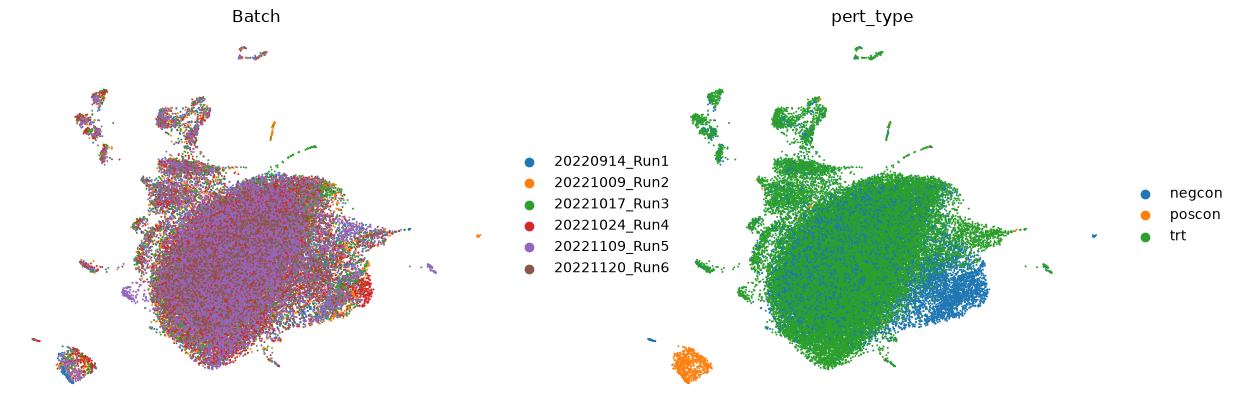

In [11]:
sc.pl.umap(adata, color=["Batch", "pert_type"], ncols=2, frameon=False, size=8)